# À l'origine : le sac de mots

## Données

Repartons des données que nous avons mis en forme, et amenons progressivement une analyse plus avancée

In [11]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/pyshs/CUSO2026/refs/heads/main/data/css_openalex_26022026.csv")
df.head(3)

,id,type,primary_location,title,abstract_inverted_index,publication_year,publication_date,open_access,relevance_score,abstract,journal
0,https://openalex.org/W2159397589,article,"{'id': 'doi:10.1126/science.1167742', 'is_oa':...",Computational Social Science,"{'A': [0], 'field': [1], 'is': [2], 'emerging'...",2009.0,2009-02-06,"{'is_oa': True, 'oa_status': 'green', 'oa_url'...",1360.35770,A field is emerging that leverages the capacit...,Science
1,https://openalex.org/W2070907364,article,"{'id': 'doi:10.1140/epjst/e2012-01697-8', 'is_...",Manifesto of computational social science,NaN,2012.0,2012-11-01,"{'is_oa': True, 'oa_status': 'hybrid', 'oa_url...",497.82666,NaN,The European Physical Journal Special Topics
2,https://openalex.org/W3081158114,article,"{'id': 'doi:10.1126/science.aaz8170', 'is_oa':...",Computational social science: Obstacles and op...,"{'Data': [0], 'sharing,': [1], 'research': [2]...",2020.0,2020-08-28,"{'is_oa': True, 'oa_status': 'green', 'oa_url'...",438.53986,"Data sharing, research ethics, and incentives ...",Science


## Transformer le texte en nombres : le comptage de mots

### Découper en mots

In [17]:
#def couper(texte):
#    return texte.split(" ")
df = df[df["abstract"].notna()]
df["abstract"].fillna("").apply(lambda x: x.split(" ")).head()

0    [A, field, is, emerging, that, leverages, the,...
2    [Data, sharing,, research, ethics,, and, incen...
3    [The, integration, of, social, science, with, ...
5    [Abstract, Large, language, models, (LLMs), ar...
7    [Abstract, The, social, sciences, investigate,...
Name: abstract, dtype: object

### Utiliser NLTK

In [22]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
texte = "La fin de la semaine est dans quelques heures !!!"

word_tokenize(texte, language="french")

[nltk_data] Downloading package punkt to /Users/emilien/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['La',
 'fin',
 'de',
 'la',
 'semaine',
 'est',
 'dans',
 'quelques',
 'heures',
 '!',
 '!',
 '!']

Plus de manipulation sur les mots

Compter les bigrams

In [27]:
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
text = "Ceci est un test. Coucou, je fais du Python. N'est-ce-pas?"
tokens = word_tokenize(text)
bigrams = list(ngrams(tokens, 4))
bigrams

[('Ceci', 'est', 'un', 'test'),
 ('est', 'un', 'test', '.'),
 ('un', 'test', '.', 'Coucou'),
 ('test', '.', 'Coucou', ','),
 ('.', 'Coucou', ',', 'je'),
 ('Coucou', ',', 'je', 'fais'),
 (',', 'je', 'fais', 'du'),
 ('je', 'fais', 'du', 'Python'),
 ('fais', 'du', 'Python', '.'),
 ('du', 'Python', '.', "N'est-ce-pas"),
 ('Python', '.', "N'est-ce-pas", '?')]

### Préprocessing : nettoyer les données

- Beaucoup d'opérations de nettoyage, spécifiques à chaque tache

In [33]:
nltk.download("stopwords")
from nltk.corpus import stopwords

english_stopwords = list(set(stopwords.words("english")))

def generate_bigrams_nltk(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token.isalnum() and token not in english_stopwords]
    bigrams = list(ngrams(filtered_tokens, 2))
    return bigrams

generate_bigrams_nltk(df.loc[2, "abstract"])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/emilien/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('data', 'sharing'),
 ('sharing', 'research'),
 ('research', 'ethics'),
 ('ethics', 'incentives'),
 ('incentives', 'must'),
 ('must', 'improve')]

## DTM : document term matrix

Le faire à la main. Ou rapide avec Scikit-learn

In [35]:
#pip install scikit-learn

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

In [46]:
from sklearn.feature_extraction.text import CountVectorizer

# créer mon object de ML
vectorizer = CountVectorizer(stop_words=english_stopwords, 
                             ngram_range=(1, 1), 
                             max_features=800)

# appliquer sur les données
X = vectorizer.fit_transform(df["abstract"])
X = pd.DataFrame(X.toarray(),columns=list(vectorizer.get_feature_names_out()))
X

,10,12,13,14,15,19,20,2016,2019,2020,...,words,work,working,works,workshop,world,would,www,years,yet
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,14,2,3,1,1,2,2,0,0,0,...,0,3,2,0,2,6,1,6,0,1
1687,3,3,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1688,3,12,15,13,7,0,11,0,0,2,...,0,10,0,0,0,1,0,0,0,0
1689,1,0,0,0,0,0,0,0,4,0,...,0,0,0,10,0,0,0,0,0,0


## Une version un peu plus avancée

- Term Frequency-Inverse Document Frequency
    - Amélioration du DTM
- Approche souvent utilisée pour mettre en valeur les mots les plus spécifiques
- `Scikit-learn` a `TfidfVectorizer`

$$\text{TF-IDF}(t, d, D) = \left( \frac{f_{t,d}}{n_d} \right) \times \log \left(\frac{N}{\text{df}_t} \right)
$$

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stopwords_english = list(set(stopwords.words("english")))

# créer un objet
vectorizer = TfidfVectorizer(stop_words=stopwords_english, 
                             ngram_range=(1, 1), 
                             max_features=500)

# applique 
X = vectorizer.fit_transform(df["abstract"])

# mettre en forme
X = pd.DataFrame(X.toarray(),columns=list(vectorizer.get_feature_names_out()))
X

,10,13,19,2019,2020,2021,2022,2024,2025,ability,...,well,whether,within,without,word,work,working,world,years,yet
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.077279,0.0,0.078534,0.000000,0.000000,0.070214,0.000000,0.000000,0.0,0.000000
3,0.000000,0.108984,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.082556,0.000000,0.059244,0.000000,0.000000,0.0,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.118122,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,0.244070,0.063239,0.035378,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.017742,...,0.012612,0.0,0.000000,0.000000,0.000000,0.034377,0.036033,0.083400,0.0,0.015862
1687,0.065096,0.000000,0.000000,0.000000,0.044708,0.0,0.000000,0.000000,0.0,0.000000,...,0.015697,0.0,0.000000,0.039749,0.000000,0.000000,0.000000,0.000000,0.0,0.019743
1688,0.048217,0.291508,0.000000,0.000000,0.033116,0.0,0.000000,0.000000,0.0,0.000000,...,0.081390,0.0,0.000000,0.000000,0.018184,0.105642,0.000000,0.012815,0.0,0.000000
1689,0.002879,0.000000,0.000000,0.014156,0.000000,0.0,0.000000,0.009499,0.0,0.005859,...,0.000000,0.0,0.000000,0.023729,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


Les mots les plus significatifs

Distance entre deux éléments

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(X.loc[120, :].values.reshape(1, -1), 
                  X.loc[124, :].values.reshape(1, -1))

Toutes les distances, et récupérer le document le plus proche

In [59]:
from sklearn.metrics.pairwise import pairwise_distances

distances = pd.DataFrame(pairwise_distances(X, metric="cosine"))
distances[199].idxmax()

142

### Application avec le clustering

Créer la matrice de distances

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X.values, method='ward') 

Représenter la figure

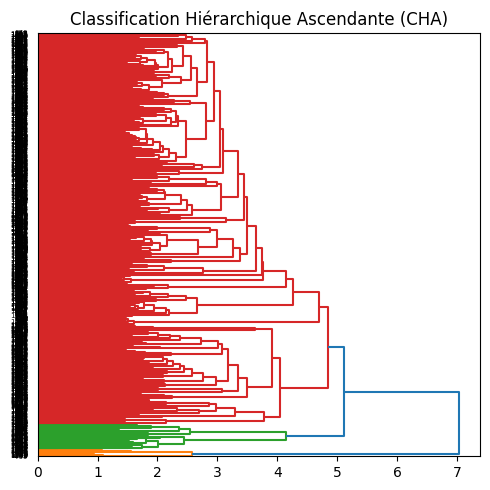

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
dendrogram(Z, orientation='right')
plt.title("Classification Hiérarchique Ascendante (CHA)")
plt.tight_layout()
plt.show()

Clustering

In [62]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=5,  linkage='ward')
labels = cluster.fit_predict(X.values)
df['cluster'] = labels

Contenu des clusters

In [79]:
df_w = pd.DataFrame(X.values, 
                    columns=vectorizer.get_feature_names_out()) 
df_w.index = df.index
df_w[df["cluster"] == 0].max().sort_values()[-20:]

topics           0.795242
development      0.800685
bias             0.812983
digital          0.821298
ai               0.823288
education        0.826056
professor        0.834855
conference       0.838771
ref              0.859978
org              0.862778
online           0.864119
urban            0.865232
sciences         0.874967
climate          0.925992
13               0.933808
la               0.946383
chapter          0.947433
de               0.957843
br               0.966966
international    1.000000
dtype: float64

## Application : Faire un nuage de mots avec WordCloud

Un coup d'oeil à la [documentation](https://amueller.github.io/word_cloud/)